<a href="https://colab.research.google.com/github/myasym/carisurg-portfolio/blob/feat%2Fweekly-updates/notebooks/2_model_development/week5_exploration_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 - Exploration & Data-Quality Assessment
### CariSurg MedTech Pathways · AI-Assisted ESI Triage Decision Support · Mercer General ED

## 1. Setup and Schema Definition
**Purpose:** To conduct a rigorous data-quality assessment and exploratory data analysis (EDA) of the Yale EMMLC triage dataset (`yaleemmlc_admissionprediction_triage.csv`). This assessment evaluates the dataset's structural integrity, missingness, distributions, and baseline correlations to determine its feasibility for training an AI-assisted ESI triage baseline model.

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [83]:
TARGET = "esi"  # Emergency Severity Index: 1 (most urgent) .. 5 (least).

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# OUTCOMES known only AFTER triage - must never be model inputs (leakage risk)
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""
    def keep_present(wanted):
        return [c for c in wanted if c in df.columns]
    chief_complaints = [c for c in df.columns if c.startswith("cc_")]
    return {
        "target": keep_present([TARGET]),
        "vitals": keep_present(VITALS),
        "demographics": keep_present(DEMOGRAPHICS),
        "admin": keep_present(ADMIN),
        "leakage": keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }

NORMAL_RANGES = {
    "triage_vital_hr": (60, 100, "bpm"), "triage_vital_sbp": (90, 140, "mmHg"),
    "triage_vital_dbp": (60, 90, "mmHg"), "triage_vital_rr": (12, 20, "/min"),
    "triage_vital_o2": (95, 100, "%"), "triage_vital_temp": (97.0, 99.5, "F"),
    "triage_glucose": (70, 140, "mg/dL"),
}

PLAUSIBLE = {
    "age": (0, 120), "esi": (1, 5), "triage_vital_hr": (20, 250), "triage_vital_sbp": (50, 300),
    "triage_vital_dbp": (20, 200), "triage_vital_rr": (4, 60), "triage_vital_o2": (50, 100),
    "triage_vital_temp": (86, 110), "triage_glucose": (20, 800),
}

UNITS = {
    "triage_vital_hr": "Pulse (bpm)", "triage_vital_sbp": "Systolic BP (mmHg)",
    "triage_vital_dbp": "Diastolic BP (mmHg)", "triage_vital_rr": "Respiratory Rate (breaths/min)",
    "triage_vital_o2": "SpO2 (%)", "triage_vital_temp": "Temperature (F)",
    "triage_glucose": "Glucose (mg/dL)", "age": "Age (years)",
}

## 2. Load the Data and First Look

In [84]:
from pathlib import Path
from google.colab import drive; drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/CariSurg/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}.")

raw = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {raw.shape[0]:,} encounters x {raw.shape[1]} columns")

fam = classify_columns(raw)
structured = [c for c in raw.columns if not c.startswith("cc_")]
print(f"Structured columns: {len(structured)}  ·  Chief-complaint flags: {len(fam['chief_complaints'])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55,121 encounters x 225 columns
Structured columns: 25  ·  Chief-complaint flags: 200


In [85]:
raw.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
raw[structured].info()

<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dep_name                55121 non-null  object 
 1   esi                     55121 non-null  float64
 2   age                     55121 non-null  float64
 3   gender                  55121 non-null  object 
 4   ethnicity               55121 non-null  object 
 5   race                    55121 non-null  object 
 6   lang                    55121 non-null  object 
 7   religion                55121 non-null  object 
 8   maritalstatus           55121 non-null  object 
 9   employstatus            55121 non-null  object 
 10  insurance_status        55121 non-null  object 
 11  disposition             55121 non-null  object 
 12  arrivalmode             55121 non-null  object 
 13  arrivalmonth            55121 non-null  object 
 14  arrivalday              55121 non-null  ob

In [87]:
raw[structured].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dep_name,55121,3,A,34933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
esi,55121.0,NaN,NaN,NaN,2.87747,0.751829,1.0,2.0,3.0,3.0,5.0
age,55121.0,NaN,NaN,NaN,55.31547,19.544287,18.0,40.0,55.0,70.0,107.0
gender,55121,2,Female,31744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,55121,4,Non-Hispanic,45142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,55121,8,White or Caucasian,29435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lang,55121,2,English,50264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
religion,55121,12,Catholic,23550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
maritalstatus,55121,10,Single,22901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employstatus,55121,10,Retired,17058,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missingness Assessment (Structured Columns)
Chief-complaint flags are binary encoded (0/1) and strictly non-null by design. Therefore, missingness is quantified across structured clinical and demographic columns.

In [88]:
missing_counts = raw[structured].isna().sum()
missing_percent = (raw[structured].isna().mean() * 100).round(2)

missingness_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent,
}).sort_values("missing_percent", ascending=False)

missingness_table

,missing_count,missing_percent
dep_name,0,0.0
esi,0,0.0
age,0,0.0
gender,0,0.0
ethnicity,0,0.0
race,0,0.0
lang,0,0.0
religion,0,0.0
maritalstatus,0,0.0
employstatus,0,0.0


In [89]:
gaps = missingness_table[missingness_table["missing_count"] > 0]
print(f"Columns with any missingness: {len(gaps)} of {len(structured)}")
gaps

Columns with any missingness: 0 of 25


,missing_count,missing_percent


**Findings:** Assessment revealed 0 columns with missingness. The absence of missing data in the structured columns is a positive finding, likely an artefact of mandatory fields in the EHR export. Consequently, the primary data-quality concern for this dataset shifts to the identification of implausible or out-of-range values.

## 4. Data Type Audit and Coercion
To ensure computational stability and reveal hidden formatting issues, vital signs and age features were subjected to defensive numeric coercion.

In [90]:
print("Dtypes (structured columns):")
print(raw[structured].dtypes)
print("\nESI (target) value counts, raw:")
print(raw[TARGET].value_counts(dropna=False).sort_index())

Dtypes (structured columns):
dep_name                   object
esi                       float64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI (target) value counts, raw:
esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name:

In [91]:
coercion_check = {}
numeric_cols = list(fam["vitals"]) + (["age"] if "age" in raw.columns else [])
for col in numeric_cols:
    before_na = raw[col].isna().sum()
    coerced = pd.to_numeric(raw[col], errors="coerce")
    after_na = coerced.isna().sum()
    coercion_check[col] = {"was_dtype": raw[col].dtype, "new_nans_from_coercion": after_na - before_na}

pd.DataFrame(coercion_check).T

,was_dtype,new_nans_from_coercion
triage_vital_hr,float64,0
triage_vital_sbp,float64,0
triage_vital_dbp,float64,0
triage_vital_rr,float64,0
triage_vital_o2,float64,0
triage_vital_temp,float64,0
triage_glucose,float64,0
age,float64,0


**Findings:** Defensive type coercion introduced 0 new NaNs, confirming that all vital signs and age values were correctly formatted as numeric data without stray text.

## 5. Outlier and Plausibility Analysis
Outliers are evaluated across two distinct parameters:
* **Statistical Outliers:** Values exceeding the 1.5 × IQR threshold.
* **Clinically Implausible Values:** Values strictly outside predefined physiological bounds (indicative of data-entry or sensor errors).

In [92]:
def outlier_report(df, col):
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()
    return {"iqr_outliers": int(iqr_outliers), "impossible": int(impossible), "n": len(x)}

outlier_rows = {col: outlier_report(raw, col) for col in fam["vitals"]}
outlier_table = pd.DataFrame(outlier_rows).T
outlier_table["impossible_pct"] = (outlier_table["impossible"] / outlier_table["n"] * 100).round(3)
outlier_table

,iqr_outliers,impossible,n,impossible_pct
triage_vital_hr,578,0,55121,0.000
triage_vital_sbp,1028,0,55121,0.000
triage_vital_dbp,726,0,55121,0.000
triage_vital_rr,2366,4,55121,0.007
triage_vital_o2,1505,0,55121,0.000
triage_vital_temp,3554,0,55121,0.000
triage_glucose,5673,25,55121,0.045


**Findings:** Two vital signs contained clinically impossible values: `triage_vital_rr` (4 instances, 0.007%) and `triage_glucose` (25 instances, 0.045%). Given the extreme rarity of these occurrences, they are highly likely to be data-entry errors.

## 6. Distribution Analysis

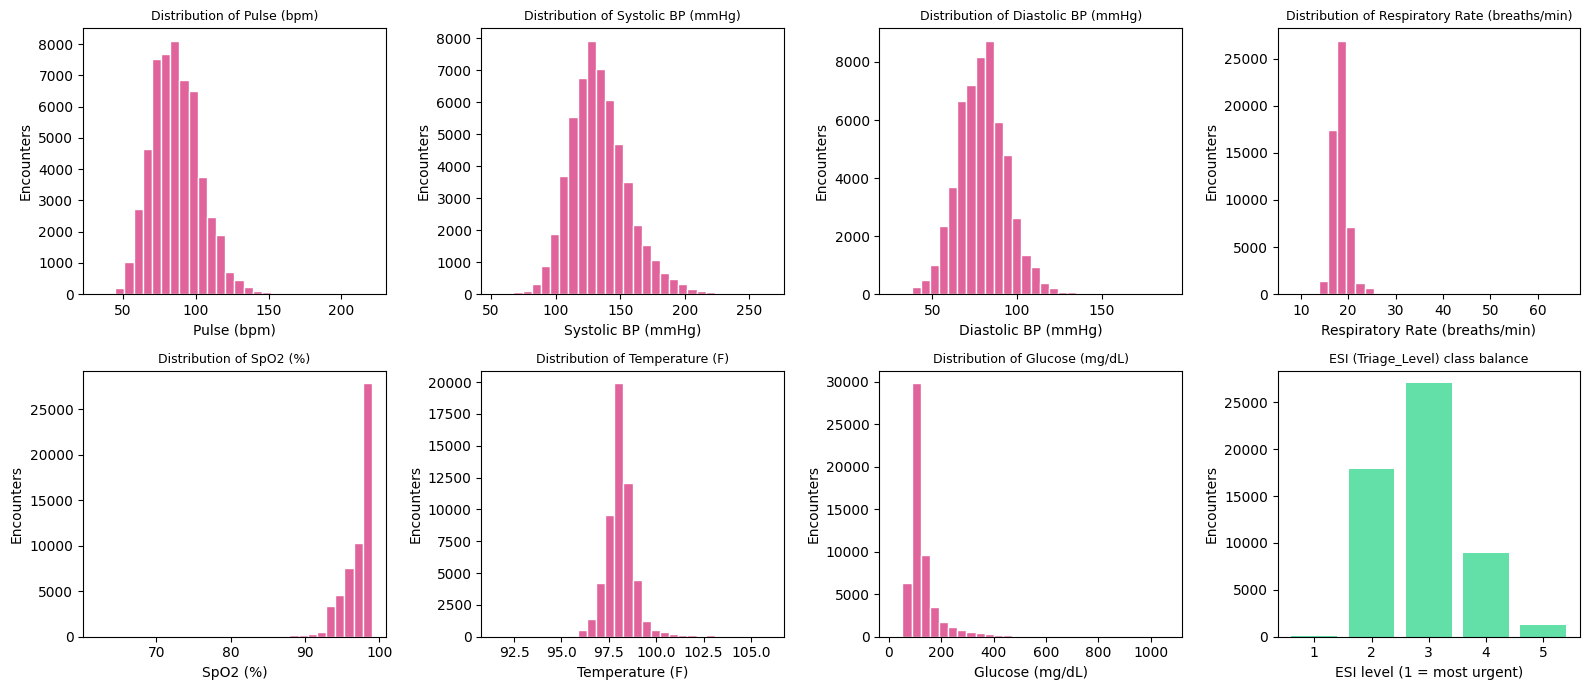

In [93]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
panels = axes.ravel()

for panel, col in zip(panels, fam["vitals"]):
    values = pd.to_numeric(raw[col], errors="coerce").dropna()
    panel.hist(values, bins=30, color="#e0639b", edgecolor="white")
    panel.set_title(f"Distribution of {UNITS.get(col, col)}", fontsize=9)
    panel.set_xlabel(UNITS.get(col, col))
    panel.set_ylabel("Encounters")

esi_counts = raw[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values, color="#63e0a8")
panels[-1].set_title("ESI (Triage_Level) class balance", fontsize=9)
panels[-1].set_xlabel("ESI level (1 = most urgent)")
panels[-1].set_ylabel("Encounters")

plt.tight_layout()
os.makedirs("figs", exist_ok=True)
plt.savefig("figs/07_vital_distributions.png", dpi=110)
plt.show()

**Findings:** Pulse, Systolic BP, Diastolic BP, and Temperature exhibit roughly normal distributions. Respiratory Rate and Glucose demonstrate strong right-skewed distributions with long clinical tails. SpO2 is heavily left-skewed, expectedly clustering near 100%. Age shows a fairly broad distribution peaking between 50 and 60 years.

## 7. Demographic Profile and Equity Considerations
To evaluate potential bias and fairness constraints, the demographic composition of the dataset was analysed, focusing on gender, race, ethnicity, and insurance status.

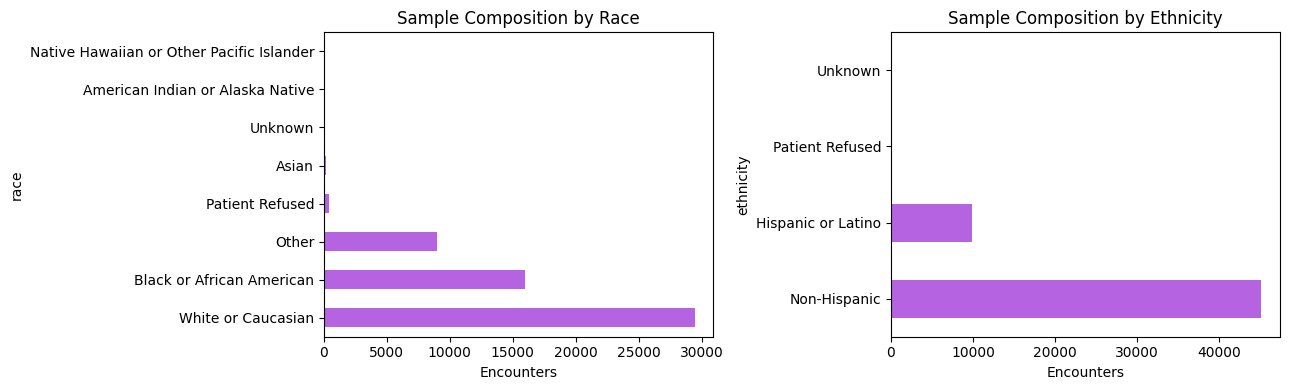

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

race_counts = raw["race"].value_counts()
race_counts.plot.barh(ax=ax[0], color="#b563e0")
ax[0].set_title("Sample Composition by Race")
ax[0].set_xlabel("Encounters")

eth_counts = raw["ethnicity"].value_counts()
eth_counts.plot.barh(ax=ax[1], color="#b563e0")
ax[1].set_title("Sample Composition by Ethnicity")
ax[1].set_xlabel("Encounters")

plt.tight_layout()
plt.savefig("figs/03_demographics.png", dpi=110)
plt.show()

In [95]:
for col in ["gender", "insurance_status"]:
    print(f"{col}:")
    print(raw[col].value_counts(dropna=False), "\n")

gender:
gender
Female    31744
Male      23377
Name: count, dtype: int64 

insurance_status:
insurance_status
Medicaid      21427
Medicare      17581
Commercial    14056
Other          1883
Self pay        174
Name: count, dtype: int64 



**Findings:** The sample is dominated by Female (31,744), Non-Hispanic (45,142), and White/Caucasian (29,435) patients, with insurance status heavily skewed toward Medicaid (21,427) and Medicare (17,581). The equity risk is that a model trained on this data may overfit to the presentation patterns of older, insured, non-minority populations, limiting external validity.

## 8. Chief-Complaint Prevalence
The ~200 binary chief-complaint (`cc_*`) flags were aggregated into body systems to assess feature sparsity and distribution.

In [96]:
CC_CATEGORIES = [
    ("Cardiovascular", ["chestpain", "chesttightness", "palpitation", "irregularheart", "rapidheart", "tachycard", "hypertens"]),
    ("Genitourinary/Renal", ["dysuria", "hematuria", "urinary", "flank", "testicle", "maleguproblem", "femaleguproblem", "groin"]),
    ("Respiratory", ["breathing", "shortnessofbreath", "dyspnea", "cough", "wheez", "respiratory", "asthma", "hemoptysis"]),
    ("Neurological", ["headache", "migraine", "dizz", "syncope", "seizure", "stroke", "alteredmental", "confusion", "numbne"]),
    ("Gastrointestinal", ["abdominal", "epigastric", "nausea", "emesis", "vomit", "diarrhea", "constipation", "gibleeding", "gi"]),
    ("Psych/Behavioural/Substance", ["anxiety", "depress", "agitation", "suicid", "homicid", "psychot", "psychiatric", "panic", "alcohol"]),
    ("ENT/Eye/Dental", ["earpain", "earproblem", "otalgia", "eye", "conjunctiv", "foreignbodyineye", "blurredvision", "dental"]),
    ("Skin/Soft-tissue", ["rash", "cellulitis", "abscess", "cyst", "skin", "wound", "mass", "allergicreaction", "edema", "bruisi"]),
    ("Endocrine/Metabolic/Heme", ["bloodsugar", "glycem", "glucose", "sicklecell"]),
    ("Constitutional/General", ["fever", "chills", "fatigue", "bodyache", "generalizedbody", "weakness"]),
    ("Trauma/Injury/MSK", ["injury", "fall", "trauma", "laceration", "fracture", "back", "neck", "joint", "rib", "assault", "burn"]),
]

def categorise(flag):
    stem = flag[3:]
    if "crash" in stem:
        return "Trauma/Injury/MSK"
    for category, keywords in CC_CATEGORIES:
        if any(k in stem for k in keywords):
            return category
    return "Other/Procedural/Admin"

from collections import defaultdict
groups = defaultdict(list)
for flag in fam["chief_complaints"]:
    groups[categorise(flag)].append(flag)

order = [name for name, _ in CC_CATEGORIES] + ["Other/Procedural/Admin"]
for name in order:
    print(f"{name:28s} {len(groups[name]):3d} flags")

Cardiovascular                 7 flags
Genitourinary/Renal           10 flags
Respiratory                    9 flags
Neurological                  15 flags
Gastrointestinal              19 flags
Psych/Behavioural/Substance   11 flags
ENT/Eye/Dental                11 flags
Skin/Soft-tissue              13 flags
Endocrine/Metabolic/Heme       5 flags
Constitutional/General         9 flags
Trauma/Injury/MSK             31 flags
Other/Procedural/Admin        60 flags


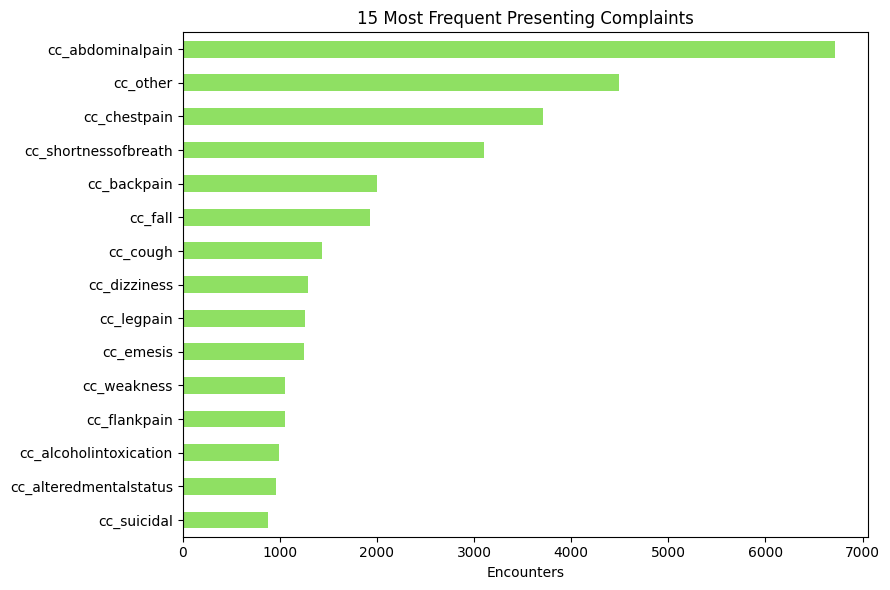

In [97]:
cc_totals = raw[fam["chief_complaints"]].sum().sort_values(ascending=False)
top15 = cc_totals.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top15[::-1].plot.barh(ax=ax, color="#8fe063")
ax.set_title("15 Most Frequent Presenting Complaints")
ax.set_xlabel("Encounters")
plt.tight_layout()
plt.savefig("figs/04_chief_complaints.png", dpi=110)
plt.show()

In [98]:
prevalence_pct = (raw[fam["chief_complaints"]].sum() / len(raw) * 100)
near_constant = prevalence_pct[prevalence_pct < 0.5]
print(f"Near-constant cc_ flags (<0.5% prevalence): {len(near_constant)} of {len(fam['chief_complaints'])}")
print(f"({len(near_constant) / len(fam['chief_complaints']) * 100:.1f}% of all chief-complaint flags)")

Near-constant cc_ flags (<0.5% prevalence): 149 of 200
(74.5% of all chief-complaint flags)


**Findings:** With 149 flags (74.5%) occurring in less than 0.5% of encounters, the dataset contains a high proportion of sparse features. This implies a strong need for dimensionality reduction or a minimum-prevalence filter in Week 6. The highest volume systems are Other/Procedural/Admin (60 flags), Trauma/Injury/MSK (31 flags), and Gastrointestinal (19 flags).

## 9. Cleaning Pipeline
The following deterministic cleaning steps were applied to prepare the dataset for downstream modelling:

| Step | Rationale |
|---|---|
| **Drop missing `esi` targets** | Models require ground-truth labels to learn decision boundaries. |
| **Numeric coercion of vitals/age** | Resolves hidden type conflicts and standardises inputs. |
| **Implausible values → NaN** | Prevents the model from learning fabricated extreme physiology. |
| **Median-fill for Vitals** | A robust baseline imputation method that preserves encounters. |
| **Fill `cc_*` and `o2_device` with 0** | Unrecorded flags are assumed absent by clinical definition. |
| **Fill missing text with "Unknown"** | Explicitly encodes the absence of data without dropping rows. |
| **Round `esi` to integers** | Aligns with the discrete 1–5 ESI scale. |

In [99]:
def clean_triage(raw_df):
    d = raw_df.copy()
    fam_local = classify_columns(d)

    d = d[d[TARGET].notna()].copy()

    numeric_cols = list(fam_local["vitals"])
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    for col in PLAUSIBLE:
        if col in d.columns:
            low, high = PLAUSIBLE[col]
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    for col in fam_local["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam_local["chief_complaints"]:
        d[col] = d[col].fillna(0)
    for col in fam_local["demographics"] + fam_local["admin"] + fam_local["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    d[TARGET] = d[TARGET].round().astype(int)
    return d

rows_before = raw.shape[0]
df = clean_triage(raw)
rows_after = df.shape[0]
fam = classify_columns(df)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Rows dropped (no ESI label): {rows_before - rows_after:,}")

Rows before cleaning: 55,121
Rows after cleaning:  55,121
Rows dropped (no ESI label): 0


**Findings:** 0 rows were dropped during the cleaning phase. The dataset shape remains 55,121 encounters, confirming the finding that zero `esi` labels are missing.

In [100]:
df.to_csv("triage_cleaned_v1.csv")
print("Saved: triage_cleaned_v1.csv")

Saved: triage_cleaned_v1.csv


## 10. Baseline Feature Correlations

In [101]:
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vitals vs ESI (negative = tracks higher acuity):")
print(vital_corr.round(3))

Vitals vs ESI (negative = tracks higher acuity):
triage_vital_rr     -0.097
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64


In [102]:
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("Chief complaints most associated with HIGH acuity (most negative):")
print(cc_corr.head(10).round(3))
print("\nChief complaints most associated with LOW acuity (most positive):")
print(cc_corr.tail(10).round(3))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Chief complaints most associated with HIGH acuity (most negative):
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
cc_sicklecellpain          -0.070
cc_gibleeding              -0.068
dtype: float64

Chief complaints most associated with LOW acuity (most positive):
cc_medicationrefill        0.090
cc_earpain                 0.093
cc_motorvehiclecrash       0.095
cc_footpain                0.099
cc_suture/stapleremoval    0.105
cc_sorethroat              0.108
cc_kneepain                0.116
cc_dentalpain              0.127
cc_rash                    0.134
cc_backpain                0.142
dtype: float64


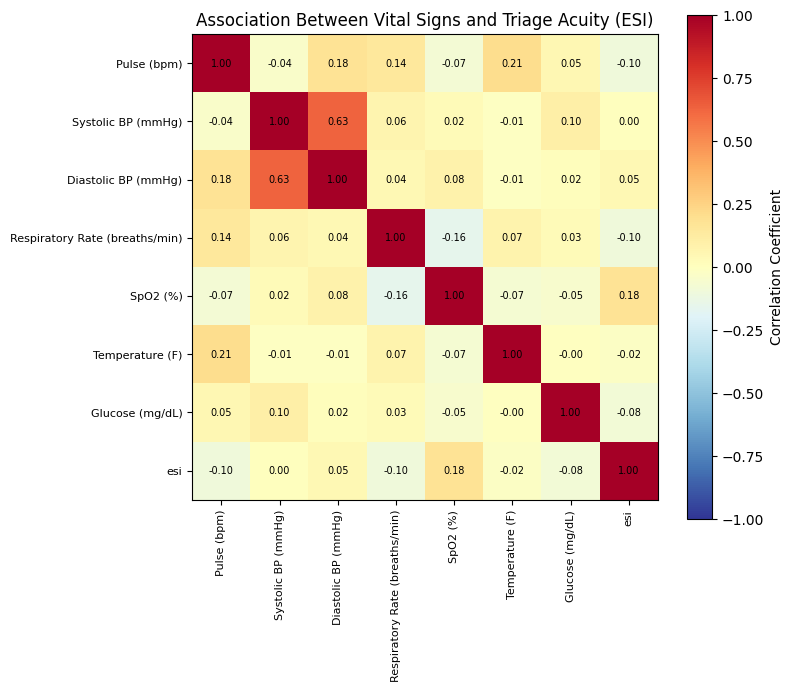

In [103]:
cols = fam["vitals"] + [TARGET]
corr_matrix = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap="RdYlBu_r", vmin=-1, vmax=1)

labels = [UNITS.get(c, c) for c in cols]
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

ax.set_title("Association Between Vital Signs and Triage Acuity (ESI)")
fig.colorbar(im, ax=ax, label="Correlation Coefficient")
plt.tight_layout()
plt.savefig("figs/06_correlation.png", dpi=110)
plt.show()

**Findings:** The strongest vital sign correlation is Oxygen Saturation (SpO2) at +0.178, which is clinically plausible as lower SpO2 dictates urgent intervention. The strongest chief complaint is Chest Pain at -0.164, a well-established high-acuity red flag. Note: Correlations represent linear associations and do not imply causation.

## 11. Class Separation by Vital Signs

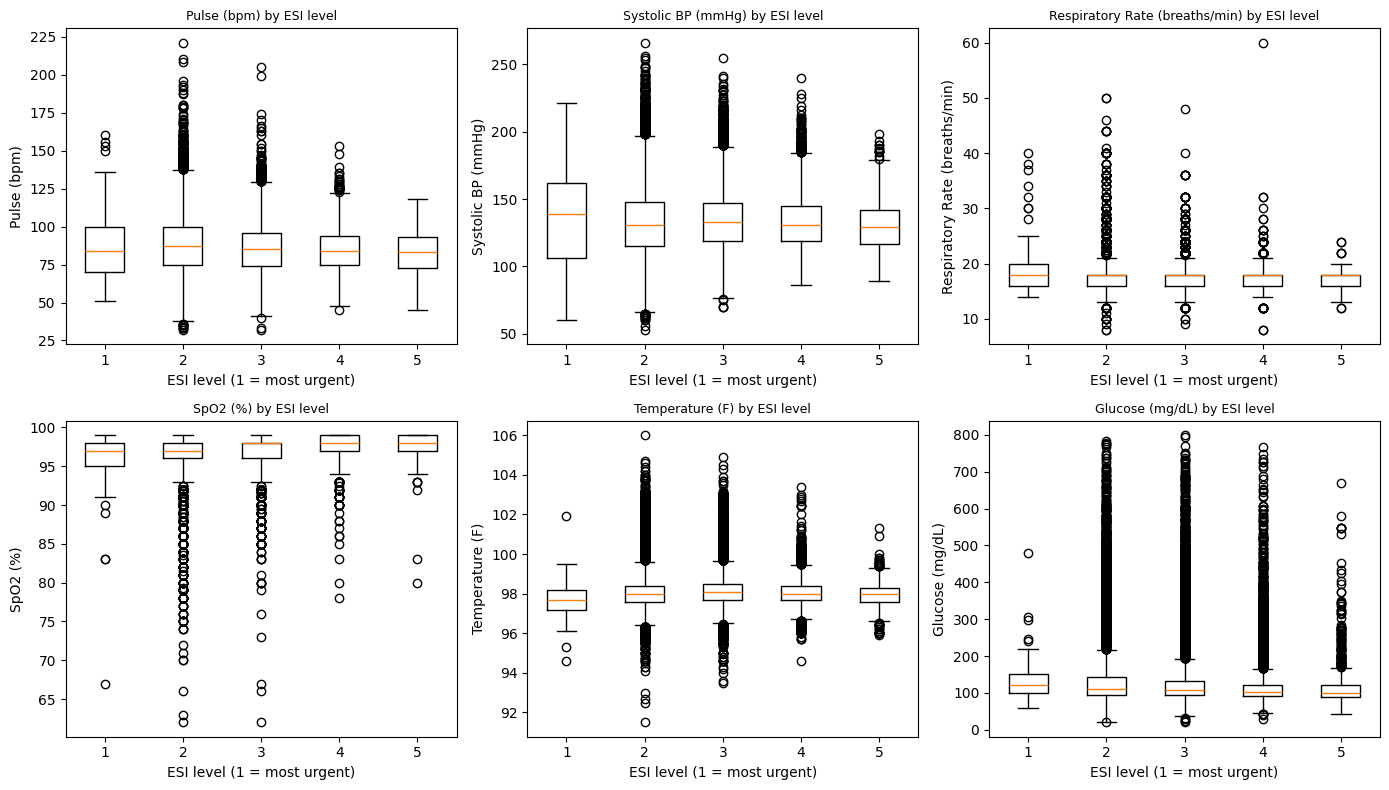

In [104]:
vitals_to_plot = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_rr",
                   "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
esi_levels = sorted(df[TARGET].unique())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for panel, col in zip(axes.ravel(), vitals_to_plot):
    groups_data = [df.loc[df[TARGET] == level, col] for level in esi_levels]
    panel.boxplot(groups_data, tick_labels=esi_levels)
    panel.set_title(f"{UNITS.get(col, col)} by ESI level", fontsize=9)
    panel.set_xlabel("ESI level (1 = most urgent)")
    panel.set_ylabel(UNITS.get(col, col))

plt.tight_layout()
plt.savefig("figs/05_vitals_by_esi.png", dpi=110)
plt.show()

**Findings:** Visual inspection of the boxplots indicates that SpO2 and Respiratory Rate exhibit the clearest separation across ESI classes, with high-acuity groups showing notably wider variance and extreme median values. Conversely, Temperature and Blood Pressure show little to no separation, suggesting weaker individual predictive power.

## 12. Missingness Heatmap

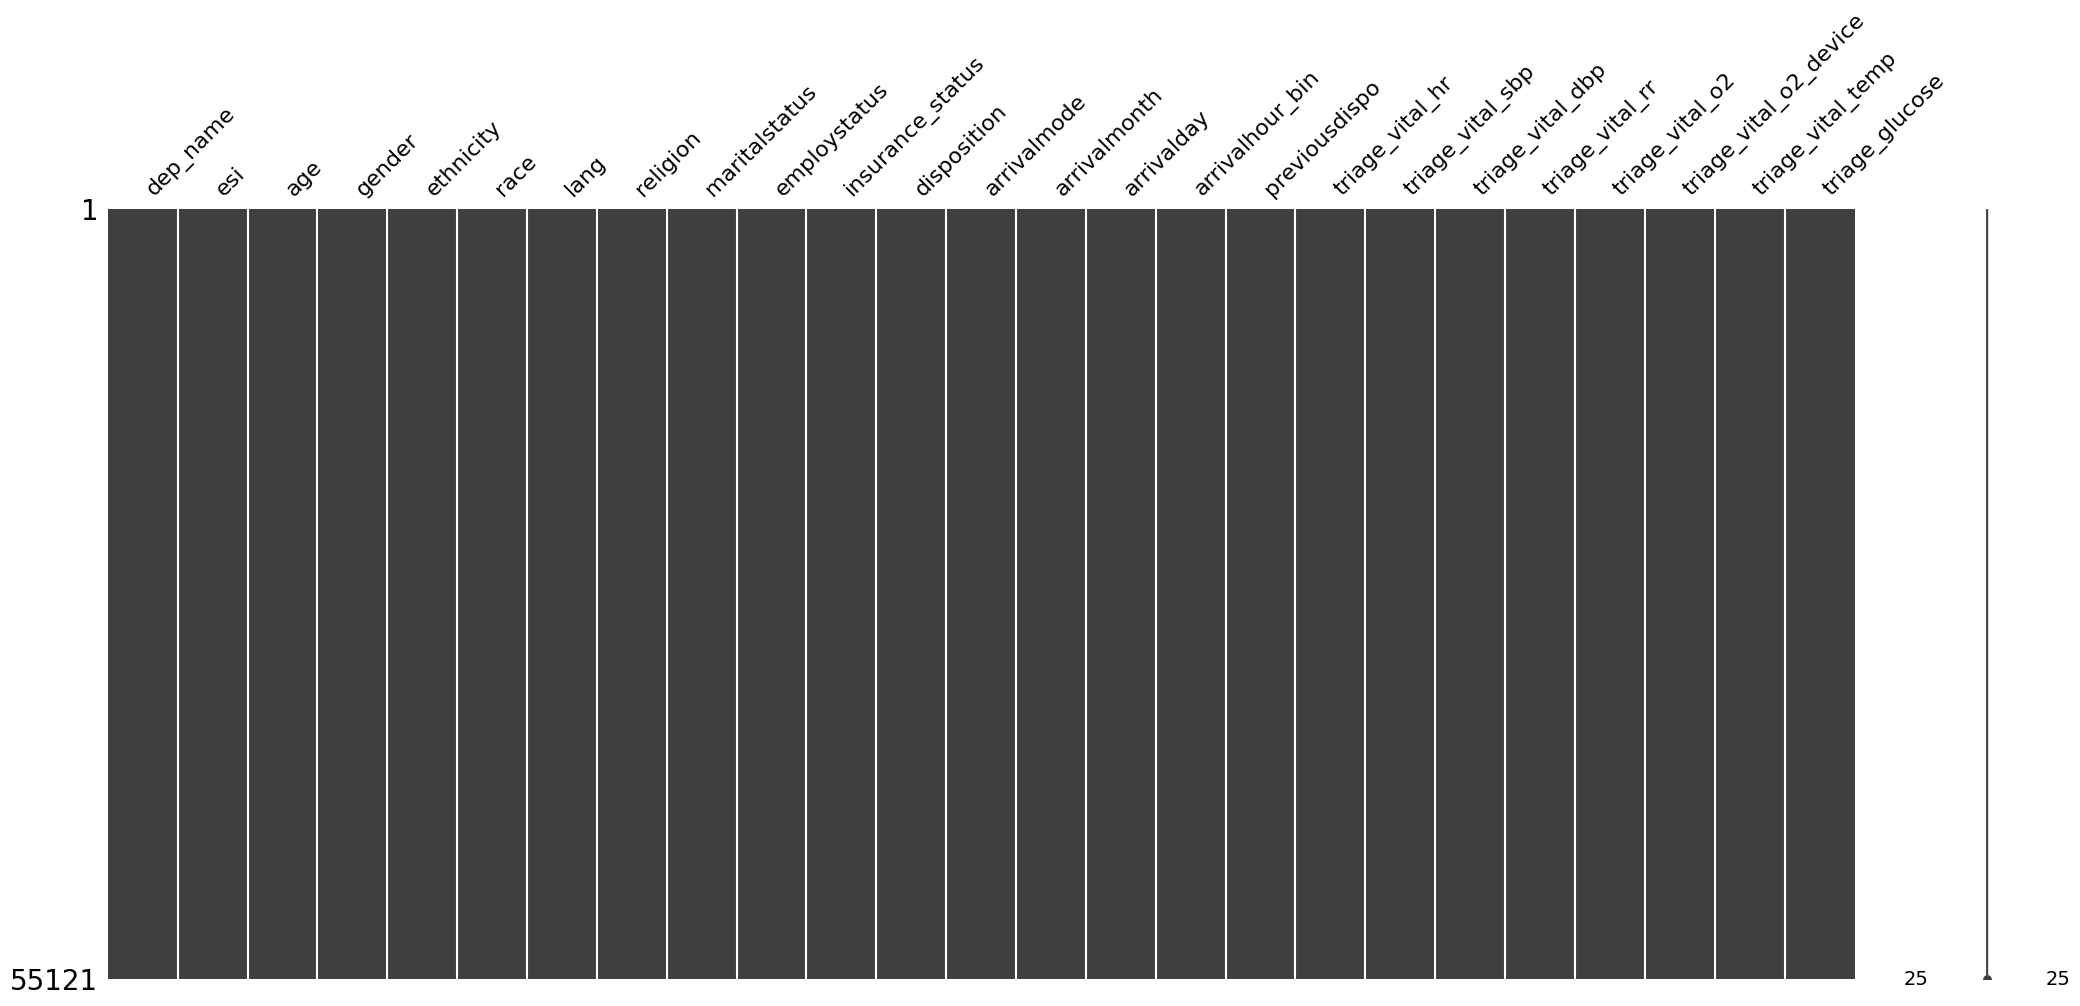

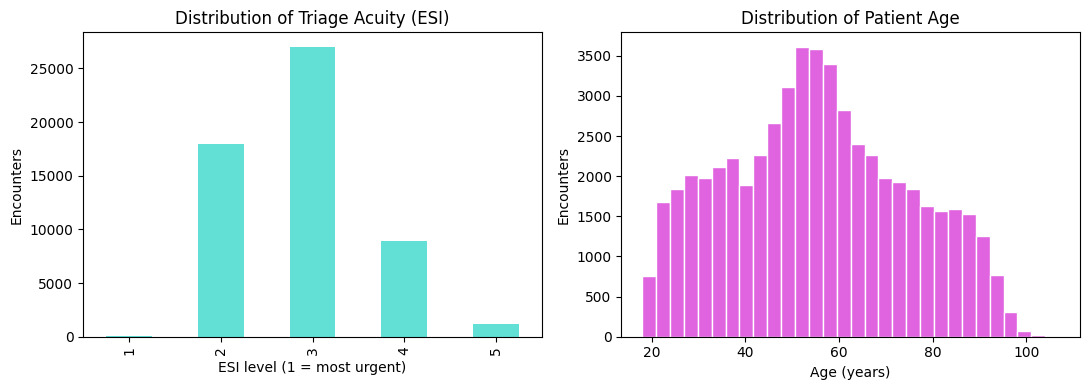

<Figure size 640x480 with 0 Axes>

In [105]:
try:
    import missingno as msno
    msno.matrix(raw[structured])
    plt.savefig("figs/01_missingness.png", dpi=110)
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(raw[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured)))
    ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing data by field (structured columns) — dark = missing")
    plt.tight_layout()
    plt.savefig("figs/01_missingness.png", dpi=110)
    plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
esi_counts_plot = df[TARGET].value_counts().sort_index()
esi_counts_plot.plot.bar(ax=ax[0], color="#63e0d5")
ax[0].set_title("Distribution of Triage Acuity (ESI)")
ax[0].set_xlabel("ESI level (1 = most urgent)")
ax[0].set_ylabel("Encounters")

ax[1].hist(df["age"], bins=30, color="#e063df", edgecolor="white")
ax[1].set_title("Distribution of Patient Age")
ax[1].set_xlabel(UNITS["age"])
ax[1].set_ylabel("Encounters")

plt.tight_layout()
plt.show()
plt.savefig("figs/02_esi_age.png", dpi=110)

## 13. Data-Quality Issues Table

In [106]:
issues = [
    {"issue": "Clinically impossible RR & glucose values", "columns": "triage_vital_rr, triage_glucose", "action": "Set out-of-bounds values to NaN, then impute with column median."},
    {"issue": "Fahrenheit temperature unit", "columns": "triage_vital_temp", "action": "Document unit explicitly to prevent misinterpretation in non-US deployment contexts."},
    {"issue": "High prevalence of near-constant features", "columns": "149 sparse cc_* flags", "action": "Apply minimum-prevalence filtering or dimensionality reduction prior to modelling."},
    {"issue": "Outcome Leakage", "columns": "disposition, previousdispo", "action": "Exclude from all feature matrices; data is only known post-triage."},
    {"issue": "Demographic Representativeness", "columns": "N/A (Dataset-level)", "action": "Log as primary external validity caveat; Caribbean validation required."}
]
pd.DataFrame(issues)

,issue,columns,action
0,Clinically impossible RR & glucose values,"triage_vital_rr, triage_glucose","Set out-of-bounds values to NaN, then impute w..."
1,Fahrenheit temperature unit,triage_vital_temp,Document unit explicitly to prevent misinterpr...
2,High prevalence of near-constant features,149 sparse cc_* flags,Apply minimum-prevalence filtering or dimensio...
3,Outcome Leakage,"disposition, previousdispo",Exclude from all feature matrices; data is onl...
4,Demographic Representativeness,N/A (Dataset-level),Log as primary external validity caveat; Carib...


## 14. Top-10 Feature Shortlist

In [107]:
candidate_corr = pd.concat([vital_corr, cc_corr]).dropna()
ranked_by_magnitude = candidate_corr.reindex(candidate_corr.abs().sort_values(ascending=False).index)
ranked_by_magnitude.head(20)

,0
triage_vital_o2,0.177859
cc_chestpain,-0.164328
cc_shortnessofbreath,-0.150285
cc_suicidal,-0.142603
cc_backpain,0.142140
cc_alcoholintoxication,-0.142127
cc_rash,0.133698
cc_alteredmentalstatus,-0.131958
cc_dentalpain,0.126720
cc_kneepain,0.115690


In [108]:
shortlist = [
    {"rank": 1, "feature": "triage_vital_o2", "correlation": "+0.178", "clinical_justification": "Low SpO2 is a universally recognised respiratory danger-zone vital requiring immediate intervention."},
    {"rank": 2, "feature": "cc_chestpain", "correlation": "-0.164", "clinical_justification": "Classic high-acuity red flag indicating potential cardiac or pulmonary emergencies."},
    {"rank": 3, "feature": "cc_shortnessofbreath", "correlation": "-0.150", "clinical_justification": "Core ESI-2 trigger reflecting acute respiratory distress."},
    {"rank": 4, "feature": "cc_suicidal", "correlation": "-0.143", "clinical_justification": "Psychiatric emergencies posing immediate risk to life require high-acuity designation."},
    {"rank": 5, "feature": "cc_backpain", "correlation": "+0.142", "clinical_justification": "Routine musculoskeletal complaint; reliably associates with lower acuity allocations."},
    {"rank": 6, "feature": "cc_alcoholintoxication", "correlation": "-0.142", "clinical_justification": "Intoxication presents airway and safety risks requiring urgent monitoring."},
    {"rank": 7, "feature": "cc_rash", "correlation": "+0.134", "clinical_justification": "Isolated rashes generally require lower ED resource utilisation."},
    {"rank": 8, "feature": "cc_alteredmentalstatus", "correlation": "-0.132", "clinical_justification": "Classic neurological/metabolic red flag dictating immediate assessment."},
    {"rank": 9, "feature": "cc_dentalpain", "correlation": "+0.127", "clinical_justification": "Non-urgent, routine presentation correlating with low acuity."},
    {"rank": 10, "feature": "cc_kneepain", "correlation": "+0.116", "clinical_justification": "Routine musculoskeletal complaint correlating with low acuity."}
]
pd.DataFrame(shortlist)

,rank,feature,correlation,clinical_justification
0,1,triage_vital_o2,+0.178,Low SpO2 is a universally recognised respirato...
1,2,cc_chestpain,-0.164,Classic high-acuity red flag indicating potent...
2,3,cc_shortnessofbreath,-0.150,Core ESI-2 trigger reflecting acute respirator...
3,4,cc_suicidal,-0.143,Psychiatric emergencies posing immediate risk ...
4,5,cc_backpain,+0.142,Routine musculoskeletal complaint; reliably as...
5,6,cc_alcoholintoxication,-0.142,Intoxication presents airway and safety risks ...
6,7,cc_rash,+0.134,Isolated rashes generally require lower ED res...
7,8,cc_alteredmentalstatus,-0.132,Classic neurological/metabolic red flag dictat...
8,9,cc_dentalpain,+0.127,"Non-urgent, routine presentation correlating w..."
9,10,cc_kneepain,+0.116,Routine musculoskeletal complaint correlating ...


## 15. Summary and Feasibility Verdict
* **Dataset Scale:** 55,121 encounters and 225 features; target labels (ESI 1-5) fully intact.
* **Missingness:** 0% missingness observed in structured columns (due to prior cleaning)
* **Outliers:** 29 total instances of physiologically impossible vital signs handled via median imputation.
* **Predictive Signals:** SpO2, Chest Pain, and Shortness of Breath show clinically logical correlations with triage acuity.
* **Sparsity:** 74.5% of chief complaints are near-constant, necessitating feature selection.
* **Equity Risk:** Demographics reflect a specific US-based, insured population, raising external validity concerns.
* **Verdict:** The dataset's structural completeness is sufficient to proceed with baseline ESI triage modelling in Week 6. However, its sparse feature space, weak linear signals, and demographic biases mean the resulting model will be computationally viable but contextually fragile. Proceed with strict methodological guardrails.